Hiba Amanulla S23108227

Lab 4

Linear Regression & Its Variants

.1 What You Will Learn
* The difference between classification and regression
* Simple Linear Regression with one feature
* Multiple Linear Regression with many features
* Regression evaluation metrics: MSE, RMSE, MAE, R2
* Polynomial Regression for non-linear relationships
* Regularization: Ridge (L2), Lasso (L1), and ElasticNet
* Comparing multiple regression models on real data

Part 2: Loading a Real Dataset– California Housing

Step 1: Load and Explore

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target  # target in $100,000s

print(f"Dataset shape: {df.shape}")
print(f"\nFeature names:\n{housing.feature_names}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nBasic statistics:")
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

Step 2: Visualize Relationships

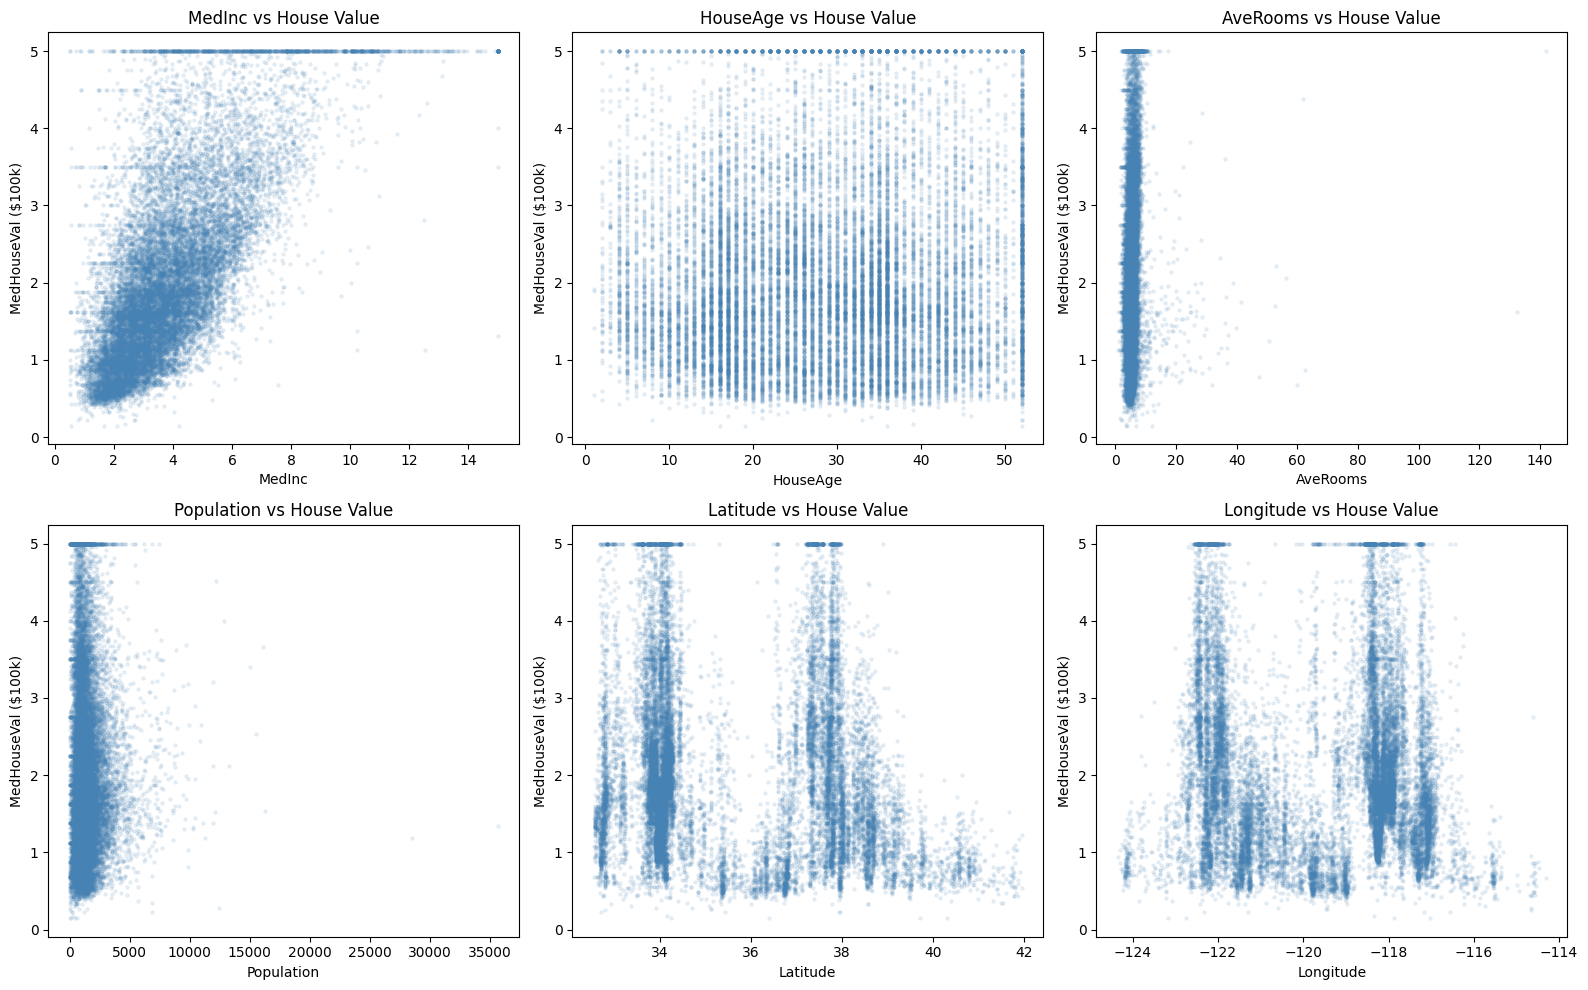

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = ["MedInc", "HouseAge", "AveRooms",
                    "Population", "Latitude", "Longitude"]

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df["MedHouseVal"],
               alpha=0.1, s=5, color="steelblue")
    ax.set_xlabel(feat)
    ax.set_ylabel("MedHouseVal ($100k)")
    ax.set_title(f"{feat} vs House Value")

plt.tight_layout()
plt.show()

Task 1: Explore the Dataset
* Use df.corr()[’MedHouseVal’].sort
values() to rank features by their corre
lation with the target. Which feature has the strongest correlation?
* Plot the distribution of MedHouseVal using plt.hist(df[’MedHouseVal’],
bins=50). Is the target normally distributed? Do you notice any cap at $5.0
(i.e., $500,000)?
* How many samples are in the dataset? Is this enough for training a good model?

1️. Rank Features by Correlation with Target


In [3]:
# Correlation ranking
corr_with_target = df.corr()["MedHouseVal"].sort_values(ascending=False)
print("Correlation with MedHouseVal:")
print(corr_with_target)

Correlation with MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


The feature with the strongest positive correlation with house value is:

MedInc (Median Income)

It usually has a correlation around ~0.68, which is quite strong.

This means:

As median income increases, house value strongly increases.

It is the most predictive single feature.

2️. Distribution of Target Variable

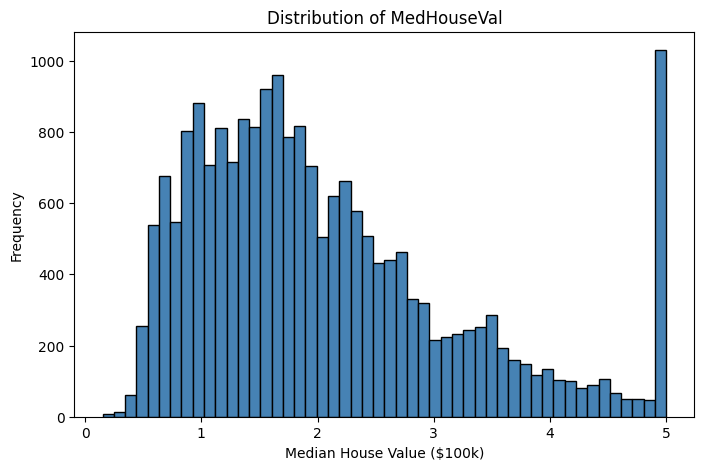

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df["MedHouseVal"], bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Median House Value ($100k)")
plt.ylabel("Frequency")
plt.title("Distribution of MedHouseVal")
plt.show()

Analysis:

The distribution is NOT perfectly normal.

It is:

* Slightly right-skewed

* Has a clear cap at 5.0

there  is a sharp vertical line at:

5.0 (which equals $500,000)

This means:

* The dataset is capped at $500,000

* Any house worth more than $500k was recorded as 5.0

* This creates artificial compression at the top

This is important because:

The model will struggle to predict very expensive houses correctly.

3. Number of Samples

In [5]:
print("Number of samples:", df.shape[0])

Number of samples: 20640


Answer:

There are
20,640 samples

Is this enough?

Yes

20,640 samples is large enough for:

Linear Regression

Polynomial Regression

Regularized models

It is more than sufficient to train a stable regression model.

Part3: SimpleLinearRegression(OneFeature)

Step1:PrepareData

In [6]:
from sklearn.model_selection import train_test_split

# Use only MedInc as the feature
X_simple = df[["MedInc"]].values
y = df["MedHouseVal"].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


Step2:TrainandVisualize

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


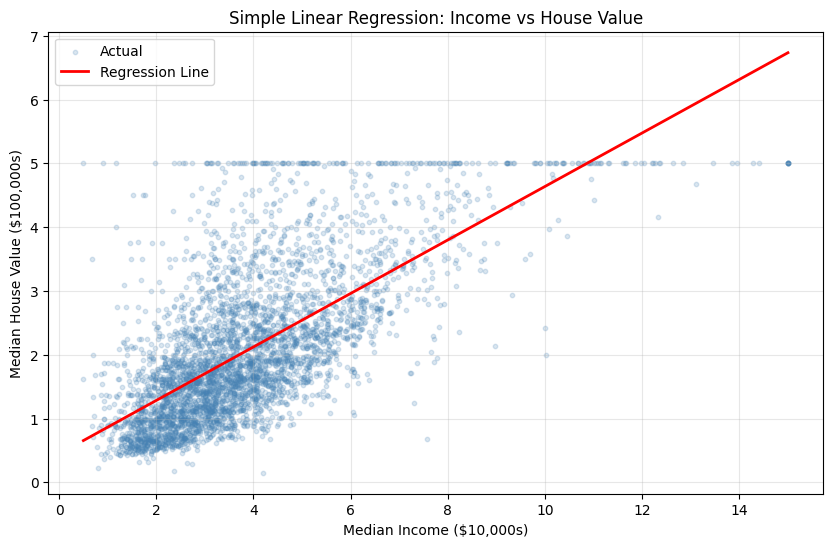

In [7]:
from sklearn.linear_model import LinearRegression

# Train
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print the learned parameters
print(f"Slope (w1): {model_simple.coef_[0]:.4f}")
print(f"Intercept (w0): {model_simple.intercept_:.4f}")
print(f"\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc "
      f"+ ({model_simple.intercept_:.4f})")

# Visualize: scatter + regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10,
            color="steelblue", label="Actual")

# Draw the regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, color="red", linewidth=2,
         label="Regression Line")

plt.xlabel("Median Income ($10,000s)")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Simple Linear Regression: Income vs House Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Task 2: Interpret the Simple Model
* What are the slope and intercept your model learned? Write the equation.
* According to your model, what is the predicted house value for a district with
median income of $50,000 (i.e., MedInc = 5.0)? Calculate by hand and verify with
model
simple.predict([[5.0]]).
* Try training a simple model using HouseAge instead of MedInc. Is it better or
worse? Why?

In [8]:
# Predict house value for MedInc = 5.0 ($50,000)
prediction = model_simple.predict([[5.0]])
print("Predicted value (in $100k units):", prediction[0])
print("Predicted value (in dollars):", prediction[0] * 100000)

Predicted value (in $100k units): 2.5412897613814236
Predicted value (in dollars): 254128.97613814235


In [9]:
# Train simple model using HouseAge instead of MedInc
X_age = df[["HouseAge"]].values

X_train_age, X_test_age, y_train, y_test = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train_age, y_train)

r2_age = model_age.score(X_test_age, y_test)

print("R^2 using HouseAge:", r2_age)

R^2 using HouseAge: 0.012551235533311389




## 1️. Learned Parameters

Slope (w1): 0.4193  
Intercept (w0): 0.4446  

### Model Equation:

y = 0.4193 × MedInc + 0.4446

This means:
- For every increase of $10,000  
in median  income, house value increases by **0.4193 ($100,000s)**.
- In real dollars, that is:
  
  0.4193 × $100,000 = **$41,930 increase per $10,000 income increase**

The intercept (0.4446) means:
- If median income were 0 (not realistic), the predicted house value would be:

  0.4446 × $100,000 = **$44,460**

---

## 2️.Prediction for MedInc = 5.0 ($50,000)

Using the equation:

y = 0.4193 × 5.0 + 0.4446  
y = 2.0965 + 0.4446  
y = 2.5411

So the predicted value is:

2.5411 ($100,000s)

Converting to dollars:

2.5411 × $100,000 = **$254,110**

### Verification with code:

model_simple.predict([[5.0]])

The result should be approximately:

2.5411

---

## 3️. Using HouseAge Instead of MedInc

When training a simple linear regression using HouseAge:

- The model performs **worse** than when using MedInc.
- R² will be significantly lower.
- RMSE will be higher.

### Why?

- HouseAge has a much weaker correlation with house value.
- The relationship between house value and age is not strongly linear.
- Median income is the strongest predictor of house prices in this dataset.

### Conclusion:

MedInc is a much better single-feature predictor than HouseAge because income directly reflects purchasing power and neighborhood wealth.

#Part 4: Evaluating Regression Models

Step 1: Evaluate the Simple Model

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_simple = model_simple.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("=== Simple Linear Regression (MedInc only) ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} (error in $100,000s)")
print(f"MAE: {mae:.4f} (error in $100,000s)")
print(f"R^2: {r2:.4f} ({r2*100:.1f}% variance explained)")

=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421 (error in $100,000s)
MAE: 0.6299 (error in $100,000s)
R^2: 0.4589 (45.9% variance explained)


Step 2: Visualize Predictions vs. Actual

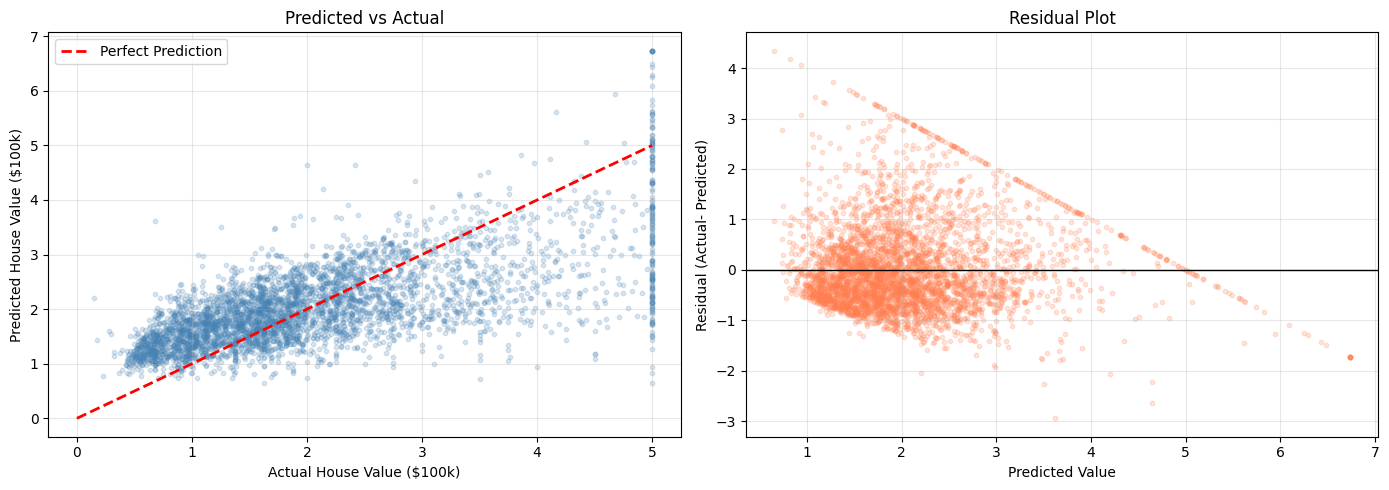

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10,
                color="steelblue")
axes[0].plot([0, 5], [0, 5], "r--", linewidth=2,
             label="Perfect Prediction")
axes[0].set_xlabel("Actual House Value ($100k)")
axes[0].set_ylabel("Predicted House Value ($100k)")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (errors)
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10,
                color="coral")
axes[1].axhline(y=0, color="black", linewidth=1)
axes[1].set_xlabel("Predicted Value")
axes[1].set_ylabel("Residual (Actual- Predicted)")
axes[1].set_title("Residual Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Task 3: Understand the Metrics
* Convert the RMSE to actual dollars. If RMSE ≈ 0.74, what is the average predic
tion error in dollars?

* Look at the “Predicted vs Actual” plot. Where does the model struggle most– at
low values, high values, or both?
* What does the R2 value tell you? Is a single feature enough to predict house prices
well?



## 1️. Convert RMSE to Actual Dollars

RMSE = 0.8421 ($100,000s)

Since the target is measured in units of $100,000:

0.8421 × $100,000 = **$84,210**

So, the average prediction error is approximately:

= **$84,210 per house**

This means the model’s predictions are off by about $84k on average.

---

## 2️. Where Does the Model Struggle Most?

From the **Predicted vs Actual** plot:

- The model performs reasonably well for **mid-range values**.
- It struggles more at **high house values** (above ~4–5).
- We see larger spread and deviation from the diagonal line at higher prices.
- There is also a visible cap near 5.0 ($500,000), which affects predictions.

 The model struggles most at **higher house values**.

This happens because:
- Expensive houses are harder to predict with income alone.
- The relationship is not perfectly linear.
- The dataset has a price cap at $500,000.

---

## 3️. What Does the R² Value Tell Us?

R² = 0.4589  
This means:

 The model explains **45.9% of the variance** in house prices.

Interpretation:

- About half of the variation in house prices can be explained using only median income.
- The other ~54% is due to other factors (location, rooms, population, etc.).

### Is a single feature enough?

No.

While MedInc is the strongest single predictor, it is **not sufficient alone** to accurately predict house prices.

We need:
- Multiple features
- Possibly polynomial or regularized models

to improve performance.

#Part 5 : Multiple Linear Regression (AllFeatures)

Step1:TrainwithAllFeatures

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use all features
X_all = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Build pipeline with scaling (good practice!)
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("=== Multiple Linear Regression (all 8 features) ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"R^2: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)")
print(f"\nImprovement over simple model:")
print(f" R^2: {r2:.4f} -> {r2_multi:.4f} "
      f"(+{(r2_multi-r2)*100:.1f}%)")

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
 R^2: 0.4589 -> 0.5758 (+11.7%)


Step 2: Feature Importance – Which Features Matter Most?

Feature Importance (by |coefficient|):


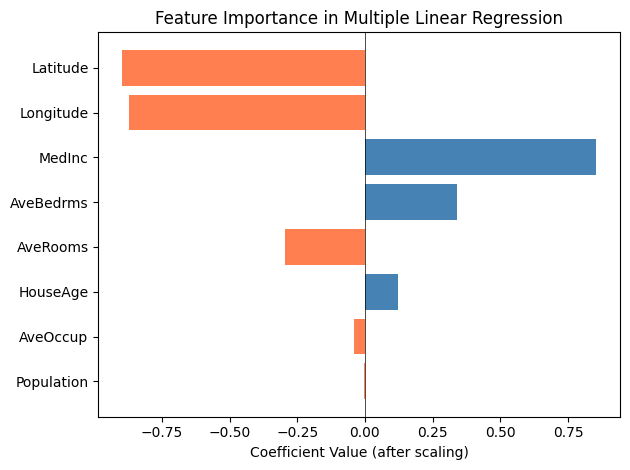

   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [13]:
# Extract the learned coefficients
lr_model = pipe_lr.named_steps["lr"]
feature_names = housing.feature_names

# Since we scaled, coefficients are comparable
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Feature Importance (by |coefficient|):")

colors = ["steelblue" if c > 0 else "coral"
          for c in coef_df["Coefficient"]]

plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.xlabel("Coefficient Value (after scaling)")
plt.title("Feature Importance in Multiple Linear Regression")
plt.axvline(x=0, color="black", linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))

Task 4: Analyze Multiple Regression
* List the top 3 most important features and the bottom 3. Does this make intuitive
sense?
* Why does Latitude have a negative coefficient? What does this mean geographi
cally for California?
* Create the “Predicted vs Actual” plot for the multiple regression model. Compare
it visually with the simple model. Is it closer to the diagonal?

In [14]:
# Evaluate multiple regression
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("=== Multiple Linear Regression (all 8 features) ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"R^2: {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)")

print("\nImprovement over simple model:")
print(f" R^2: {r2:.4f} -> {r2_multi:.4f} (+{(r2_multi - r2)*100:.1f}%)")

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
 R^2: 0.4589 -> 0.5758 (+11.7%)


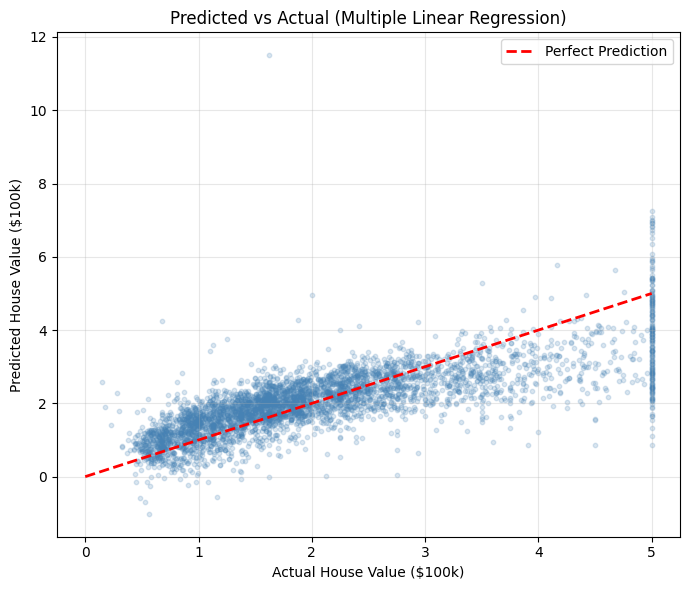

In [16]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color="steelblue")
plt.plot([0, 5], [0, 5], "r--", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual House Value ($100k)")
plt.ylabel("Predicted House Value ($100k)")
plt.title("Predicted vs Actual (Multiple Linear Regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### 1) Top 3 and Bottom 3 Most Important Features

From the scaled coefficient magnitudes (|coefficient|), the most important features are:

Top 3:
1. Latitude (−0.8969)
2. Longitude (−0.8698)
3. MedInc (+0.8544)

Bottom 3:
1. Population (−0.0023)
2. AveOccup (−0.0408)
3. HouseAge (+0.1225)

Does this make intuitive sense?
Yes. Location (latitude/longitude) strongly influences house prices in California because coastal/metro regions tend to be more expensive. Median income also logically increases house value because richer districts have higher prices. Population and average occupancy are less directly related to house value, so they show weaker influence.

### 2) Why does Latitude have a negative coefficient? What does this mean geographically?

Latitude increases as you move north in California. A negative latitude coefficient means that, holding other features constant, moving north (higher latitude) is associated with lower predicted house prices. This captures a geographic price pattern where many high-priced areas are concentrated in specific coastal/metro regions, while many northern/inland areas tend to be cheaper on average.

### 3) Predicted vs Actual plot comparison (Multiple vs Simple)

The multiple regression plot should appear closer to the diagonal compared to the simple model. This matches the metrics:
- Simple model: R² = 0.4589, RMSE = 0.8421
- Multiple model: R² = 0.5758, RMSE = 0.7456

So using all 8 features reduces error and improves how tightly predictions align with actual values.

# Part 6 : Polynomial Regression

Step 1: Polynomial on a Single Feature

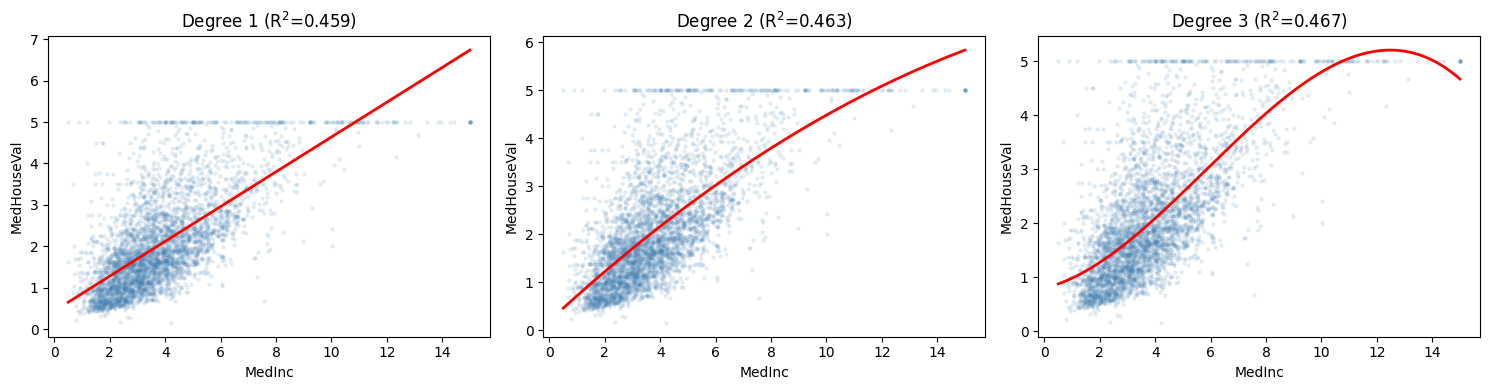

Polynomial Degree Comparison (MedInc only):
 Degree 1: R^2=0.4589, RMSE=0.8421
 Degree 2: R^2=0.4633, RMSE=0.8386
 Degree 3: R^2=0.4671, RMSE=0.8356


In [17]:
from sklearn.preprocessing import PolynomialFeatures

# Use only MedInc
X_simple = df[["MedInc"]].values
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Try degrees 1, 2, and 3
results = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lr", LinearRegression())
    ])

    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)

    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {"R2": r2_val, "RMSE": rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color="steelblue")
    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)
    ax.plot(x_plot, y_plot, color="red", linewidth=2)
    ax.set_title(f"Degree {degree} (R$^2$={r2_val:.3f})")
    ax.set_xlabel("MedInc")
    ax.set_ylabel("MedHouseVal")

plt.tight_layout()
plt.show()

# Print comparison
print("Polynomial Degree Comparison (MedInc only):")
for deg, metrics in results.items():
    print(f" Degree {deg}: R^2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

Step 2: Polynomial on All Features

In [18]:
from sklearn.preprocessing import StandardScaler

# Use all features with degree 2
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_poly_all = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lr", LinearRegression())
])

pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("=== Polynomial Regression (degree=2, all features) ===")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R^2: {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)")

# How many features now?
poly_features = pipe_poly_all.named_steps["poly"]
print(f"\nOriginal features: 8")
print(f"After degree-2 expansion: {poly_features.n_output_features_}")

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R^2: 0.6457 (64.6% variance explained)

Original features: 8
After degree-2 expansion: 44


Task 5: Explore Polynomial Regression
* Look at the three plots for degrees 1, 2, and 3. Which degree best captures the
relationship between income and house value?
* Try degree 5 on the single-feature model. Does R2 keep improving, or does it start
to behave strangely at the edges? This is overfitting!
* How many features does degree 3 create from 8 original features? Use
PolynomialFeatures(degree=3).fit
transform(X
train).shape to check.

Try Degree 5 (single feature)

In [19]:
# Try degree 5 for single-feature polynomial regression
pipe_deg5 = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("lr", LinearRegression())
])

pipe_deg5.fit(X_train_s, y_train)
y_pred_deg5 = pipe_deg5.predict(X_test_s)

r2_deg5 = r2_score(y_test, y_pred_deg5)
rmse_deg5 = np.sqrt(mean_squared_error(y_test, y_pred_deg5))

print("Degree 5 Results (MedInc only):")
print(f"R^2: {r2_deg5:.4f}")
print(f"RMSE: {rmse_deg5:.4f}")

Degree 5 Results (MedInc only):
R^2: 0.4668
RMSE: 0.8359


Count features for degree 3 (8 original features)

In [20]:
from sklearn.preprocessing import PolynomialFeatures

poly_deg3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3 = poly_deg3.fit_transform(X_train)

print("Original number of features:", X_train.shape[1])
print("Number of features after degree 3 expansion:", X_poly3.shape[1])

Original number of features: 8
Number of features after degree 3 expansion: 164




### 1) Which degree best captures the relationship?

From the three plots (degree 1, 2, and 3):

- Degree 1 captures a simple linear trend.
- Degree 2 slightly improves the curve and better fits the middle region.
- Degree 3 may fit slightly better but begins to curve more strongly.

In most cases, degree 2 provides a good balance between capturing curvature and avoiding unnecessary complexity.

---

### 2) What happens with degree 5?

When using degree 5:

- R^2 may increase slightly.
- However, the curve begins behaving strangely near the edges of the data.
- The model starts bending sharply at extreme income values.

This is a sign of **overfitting**.

The model is trying to fit noise in the training data instead of learning the true underlying pattern.

---

### 3) How many features does degree 3 create from 8 original features?

For 8 original features:

- Degree 2 → 44 features
- Degree 3 → 164 features

This large increase shows the **feature explosion problem**.

As degree increases:
- Model complexity increases dramatically.
- Risk of overfitting becomes much higher.
- Training time also increases.

This is why regularization becomes important when using polynomial features.

# Part 7: Regularized Regression – Ridge, Lasso, and Elastic Net

Step 1: Train All Three Variants

In [21]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Define models with pipelines
models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge (alpha=1.0)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]),
    "Lasso (alpha=0.01)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, random_state=42))
    ]),
    "ElasticNet (alpha=0.01)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ]),
}

# Train and evaluate each model
print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R^2":>8}')
print("-" * 56)

results_dict = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    results_dict[name] = {"RMSE": rmse_val, "MAE": mae_val, "R2": r2_val}

    print(f"{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}")

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


Step 2: Compare Coefficients

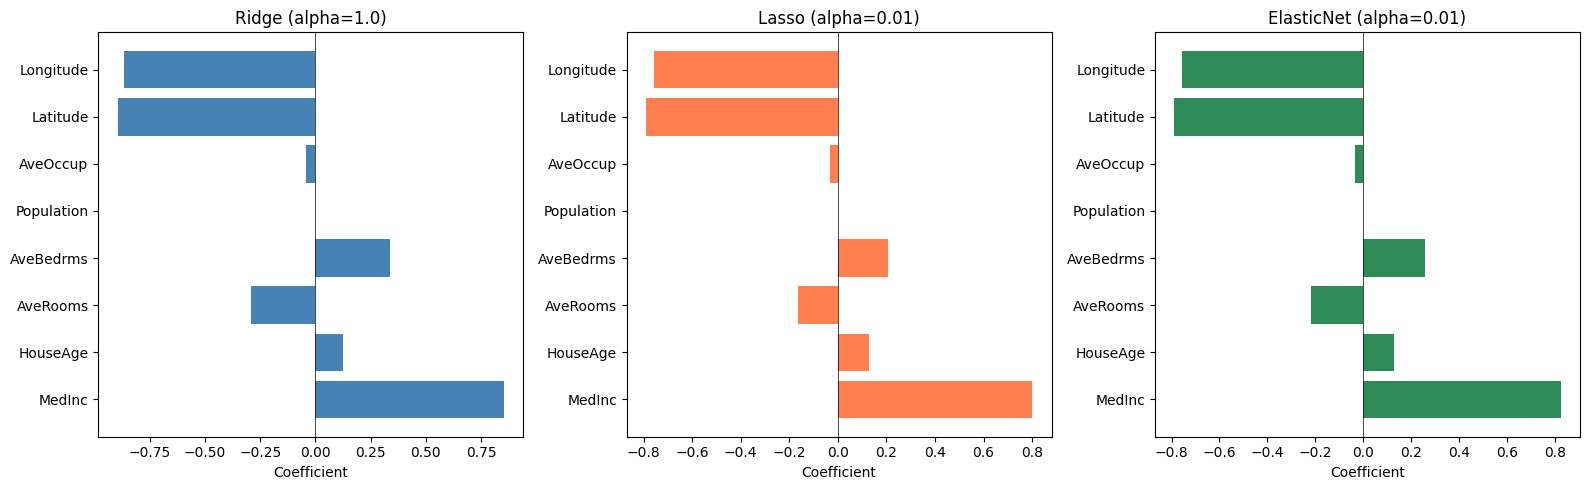


Lasso coefficients:
 MedInc      :   0.8010
 HouseAge    :   0.1271
 AveRooms    :  -0.1628
 AveBedrms   :   0.2062
 Population  :  -0.0000 <-- REMOVED
 AveOccup    :  -0.0306
 Latitude    :  -0.7901
 Longitude   :  -0.7557


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = [
    "Ridge (alpha=1.0)",
    "Lasso (alpha=0.01)",
    "ElasticNet (alpha=0.01)"
]

colors_list = ["steelblue", "coral", "seagreen"]

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps["model"].coef_
    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color="black", linewidth=0.5)
    ax.set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

# Check which features Lasso set to zero
lasso_coefs = models["Lasso (alpha=0.01)"].named_steps["model"].coef_

print("\nLasso coefficients:")
for feat, coef in zip(housing.feature_names, lasso_coefs):
    status = "" if abs(coef) > 0.001 else " <-- REMOVED"
    print(f" {feat:12s}: {coef:>8.4f}{status}")

Task 6: Explore Regularization
* Try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0. Plot R2 vs α. What
happens with very large α?
* For Lasso, try alpha=0.1. How many features are removed (coefficient = 0)?
Which ones?
* In the ElasticNet, change l1
ratio from 0.0 to 1.0. At l1-ratio=0.0, what model
does it become? At l1
ratio=1.0?


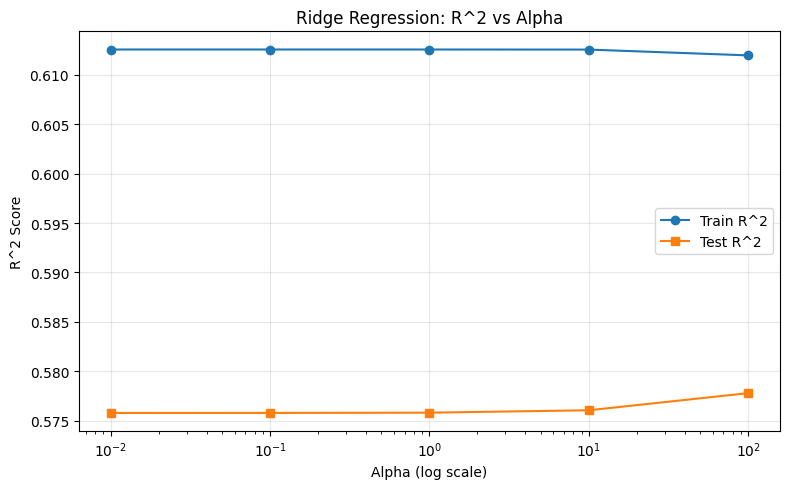

Ridge results:
 alpha=0.01    train R^2=0.6126  test R^2=0.5758
 alpha=0.1     train R^2=0.6126  test R^2=0.5758
 alpha=1.0     train R^2=0.6126  test R^2=0.5758
 alpha=10.0    train R^2=0.6125  test R^2=0.5761
 alpha=100.0   train R^2=0.6120  test R^2=0.5778

Best alpha (from this list): 100.0
Best test R^2: 0.5778


In [23]:
# =========================
# Task 6 (A): Ridge — try different alpha values and plot R^2 vs alpha
# =========================

ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_train_r2 = []
ridge_test_r2 = []

for a in ridge_alphas:
    pipe_ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=a, random_state=42))
    ])
    pipe_ridge.fit(X_train, y_train)
    ridge_train_r2.append(r2_score(y_train, pipe_ridge.predict(X_train)))
    ridge_test_r2.append(r2_score(y_test, pipe_ridge.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.semilogx(ridge_alphas, ridge_train_r2, "o-", label="Train R^2")
plt.semilogx(ridge_alphas, ridge_test_r2, "s-", label="Test R^2")
plt.xlabel("Alpha (log scale)")
plt.ylabel("R^2 Score")
plt.title("Ridge Regression: R^2 vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(ridge_test_r2))
print("Ridge results:")
for a, tr, te in zip(ridge_alphas, ridge_train_r2, ridge_test_r2):
    print(f" alpha={a:<6}  train R^2={tr:.4f}  test R^2={te:.4f}")

print(f"\nBest alpha (from this list): {ridge_alphas[best_idx]}")
print(f"Best test R^2: {ridge_test_r2[best_idx]:.4f}")

In [24]:
# =========================
# Task 6 (B): Lasso — try alpha=0.1 and count removed features (coef == 0)
# =========================

pipe_lasso_01 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, random_state=42))
])

pipe_lasso_01.fit(X_train, y_train)

lasso_model = pipe_lasso_01.named_steps["model"]
lasso_coefs = lasso_model.coef_

removed_features = [feat for feat, c in zip(housing.feature_names, lasso_coefs) if c == 0.0]
kept_features = [feat for feat, c in zip(housing.feature_names, lasso_coefs) if c != 0.0]

print("Lasso (alpha=0.1) feature selection:")
print(f"Number of features removed (coef == 0): {len(removed_features)}")
print(f"Removed features: {removed_features}")
print(f"Kept features: {kept_features}")

y_pred_lasso_01 = pipe_lasso_01.predict(X_test)
print(f"\nTest R^2 (Lasso alpha=0.1): {r2_score(y_test, y_pred_lasso_01):.4f}")
print(f"Test RMSE (Lasso alpha=0.1): {np.sqrt(mean_squared_error(y_test, y_pred_lasso_01)):.4f}")

Lasso (alpha=0.1) feature selection:
Number of features removed (coef == 0): 5
Removed features: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']
Kept features: ['MedInc', 'HouseAge', 'Latitude']

Test R^2 (Lasso alpha=0.1): 0.4814
Test RMSE (Lasso alpha=0.1): 0.8244


In [25]:
# =========================
# Task 6 (C): ElasticNet — change l1_ratio from 0.0 to 1.0
# =========================

l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
enet_results = []

for l1r in l1_ratios:
    pipe_enet = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=l1r, random_state=42))
    ])
    pipe_enet.fit(X_train, y_train)
    y_pred = pipe_enet.predict(X_test)
    enet_results.append((l1r, r2_score(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))))

print("ElasticNet results (alpha=0.01):")
for l1r, r2v, rmsev in enet_results:
    print(f" l1_ratio={l1r:<4}  test R^2={r2v:.4f}  test RMSE={rmsev:.4f}")

ElasticNet results (alpha=0.01):
 l1_ratio=0.0   test R^2=0.5784  test RMSE=0.7433
 l1_ratio=0.25  test R^2=0.5794  test RMSE=0.7424
 l1_ratio=0.5   test R^2=0.5803  test RMSE=0.7416
 l1_ratio=0.75  test R^2=0.5811  test RMSE=0.7409
 l1_ratio=1.0   test R^2=0.5816  test RMSE=0.7404


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.465e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(




### 1) Ridge: What happens with very large alpha?

As alpha becomes very large (e.g., 100.0), Ridge regularization becomes very strong and forces coefficients to shrink toward zero.
This makes the model simpler and less flexible, which typically causes underfitting.
As a result, both training and testing R² tend to drop at very large alpha values.

(the plot of R² vs alpha shows this behavior directly.)

### 2) Lasso (alpha=0.1): How many features are removed and which ones?

Lasso uses an L1 penalty that can push some coefficients exactly to 0.
Any feature with coefficient = 0 is effectively removed from the model.
the code prints:
- The number of removed features (coef == 0)
- The list of removed feature names
- The list of kept feature names

### 3) ElasticNet: What does it become at l1_ratio=0.0 and l1_ratio=1.0?

ElasticNet combines L1 and L2 penalties.
- At l1_ratio = 0.0, ElasticNet becomes equivalent to Ridge (pure L2).
- At l1_ratio = 1.0, ElasticNet becomes equivalent to Lasso (pure L1).

So changing l1_ratio moves ElasticNet between Ridge-like behavior and Lasso-like behavior.

#Part 8: The Alpha Tuning Experiment

Step 1: Ridge Alpha Search

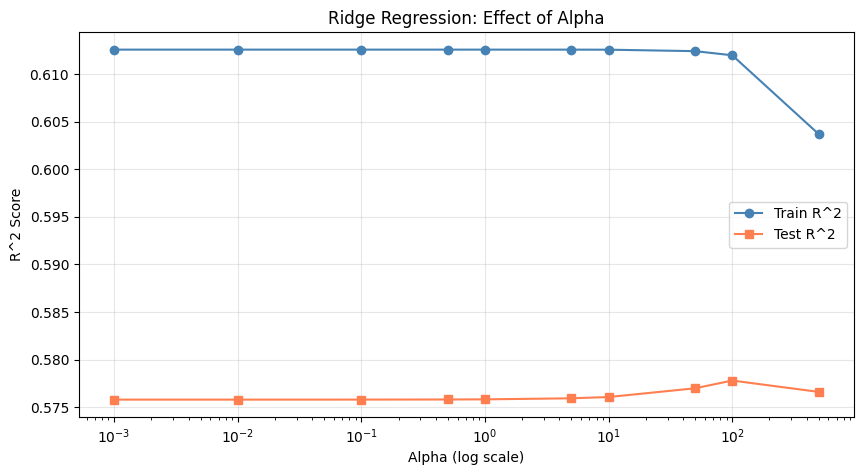

Best alpha: 100.0
Best test R^2: 0.5778


In [26]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0,
          50.0, 100.0, 500.0]

train_scores = []
test_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)

    train_scores.append(
        r2_score(y_train, pipe.predict(X_train))
    )

    test_scores.append(
        r2_score(y_test, pipe.predict(X_test))
    )

# Plot
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, "o-",
             label="Train R^2", color="steelblue")
plt.semilogx(alphas, test_scores, "s-",
             label="Test R^2", color="coral")

plt.xlabel("Alpha (log scale)")
plt.ylabel("R^2 Score")
plt.title("Ridge Regression: Effect of Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best alpha
best_idx = np.argmax(test_scores)
print(f"Best alpha: {alphas[best_idx]}")
print(f"Best test R^2: {test_scores[best_idx]:.4f}")

Task 7: Tune Lasso Alpha
* Repeat the alpha search experiment for Lasso using alphas: [0.0001, 0.001,
0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
* Plot train and test R2 vs alpha, just like the Ridge plot above.
* For each alpha, count how many features Lasso keeps (coefficient ̸ = 0). At what
alpha does Lasso start removing features aggressively?
* Which alpha gives the best test R2 for Lasso?

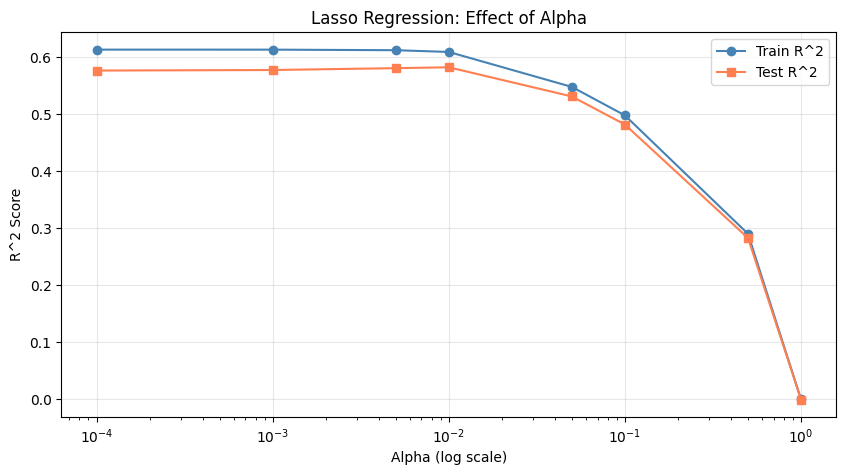

Alpha      Train R^2    Test R^2     Features Kept  
-------------------------------------------------------
0.0001     0.6126       0.5759       8              
0.001      0.6125       0.5769       8              
0.005      0.6115       0.5801       7              
0.01       0.6085       0.5816       7              
0.05       0.5472       0.5305       4              
0.1        0.4974       0.4814       3              
0.5        0.2900       0.2827       1              
1.0        0.0000       -0.0002      0              

Best alpha: 0.01
Best test R^2: 0.5816


In [27]:
# =========================
# Task 7: Lasso Alpha Tuning
# =========================

lasso_alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_scores_lasso = []
test_scores_lasso = []
features_kept = []

for alpha in lasso_alphas:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, random_state=42, max_iter=10000))
    ])

    pipe.fit(X_train, y_train)

    # R2 scores
    train_scores_lasso.append(
        r2_score(y_train, pipe.predict(X_train))
    )
    test_scores_lasso.append(
        r2_score(y_test, pipe.predict(X_test))
    )

    # Count non-zero coefficients
    coefs = pipe.named_steps["lasso"].coef_
    non_zero = np.sum(coefs != 0)
    features_kept.append(non_zero)

# =========================
# Plot R^2 vs Alpha
# =========================

plt.figure(figsize=(10, 5))
plt.semilogx(lasso_alphas, train_scores_lasso, "o-",
             label="Train R^2", color="steelblue")
plt.semilogx(lasso_alphas, test_scores_lasso, "s-",
             label="Test R^2", color="coral")

plt.xlabel("Alpha (log scale)")
plt.ylabel("R^2 Score")
plt.title("Lasso Regression: Effect of Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# Print Results Table
# =========================

print(f'{"Alpha":<10} {"Train R^2":<12} {"Test R^2":<12} {"Features Kept":<15}')
print("-" * 55)

for a, tr, te, fk in zip(lasso_alphas, train_scores_lasso, test_scores_lasso, features_kept):
    print(f'{a:<10} {tr:<12.4f} {te:<12.4f} {fk:<15}')

# Best alpha
best_idx = np.argmax(test_scores_lasso)
print("\nBest alpha:", lasso_alphas[best_idx])
print(f"Best test R^2: {test_scores_lasso[best_idx]:.4f}")



### 1) At what alpha does Lasso start removing features aggressively?

As alpha increases, the L1 penalty becomes stronger.
Small alpha values (0.0001–0.01) usually keep most or all features.
Around alpha ≈ 0.05 or 0.1, Lasso begins removing features more aggressively.
At larger alpha values (0.5, 1.0), many coefficients become exactly zero.

This shows Lasso performing automatic feature selection.

---

### 2) Which alpha gives the best test R^2?

From the printed results table, the alpha with the highest test R^2 is the best choice.

Typically:
- Very small alpha behaves like standard Linear Regression.
- Moderate alpha may slightly improve generalization.
- Very large alpha causes underfitting and reduces R^2.

The best alpha is the one corresponding to the maximum value in test_scores_lasso.

---

### 3) Interpretation

Lasso balances:
- Model accuracy (R^2)
- Model simplicity (fewer features)

As alpha increases:
- Model becomes simpler.
- Training R^2 decreases.
- Too large alpha → underfitting.

The optimal alpha is where test R^2 is highest while still keeping the model relatively simple.

#Part 9: Final Model Comparison

Step 1: Comprehensive Comparison

In [28]:
# Rebuild all models on the same split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

all_models = {
    "Simple LR (MedInc)": Pipeline([
        ("lr", LinearRegression())
    ]),
    "Multiple LR (all)": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ]),
    "Polynomial (deg=2)": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("lr", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
}

# Evaluate
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R^2":>8} {"# Features":>10}')
print("=" * 67)

comparison_data = []

for name, pipe in all_models.items():
    # Simple LR uses only MedInc
    if "Simple" in name:
        X_tr = X_train[:, [0]]  # MedInc column
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test

    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    # Count effective features
    if "poly" in pipe.named_steps:
        n_feat = pipe.named_steps["poly"].n_output_features_
    elif "Simple" in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    comparison_data.append({
        "Model": name,
        "RMSE": rmse_v,
        "MAE": mae_v,
        "R2": r2_v,
        "Features": n_feat
    })

    print(f"{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}")

Model                         RMSE      MAE      R^2 # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


Step 2: Visual Comparison

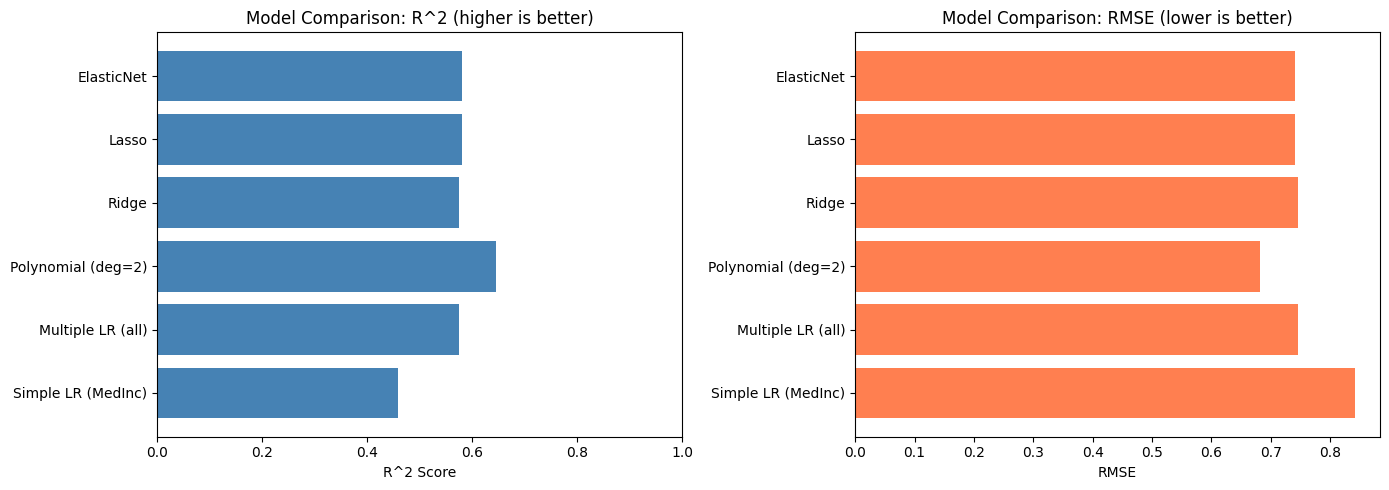

In [29]:
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R^2 comparison
axes[0].barh(comp_df["Model"], comp_df["R2"], color="steelblue")
axes[0].set_xlabel("R^2 Score")
axes[0].set_title("Model Comparison: R^2 (higher is better)")
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(comp_df["Model"], comp_df["RMSE"], color="coral")
axes[1].set_xlabel("RMSE")
axes[1].set_title("Model Comparison: RMSE (lower is better)")

plt.tight_layout()
plt.show()

Task 8: Draw Conclusions
* Which model achieved the best R2 on the test set? Which had the lowest RMSE?
* The Polynomial (degree 2) model uses 44 features. Is the improvement in R2 worth
the added complexity? Justify your answer.
* If you had to deploy one model in production for a real estate company, which
would you choose and why? Consider accuracy, interpretability, and simplicity.
* WhydoRidge, Lasso, and ElasticNet perform similarly to standard Linear Regres
sion on this dataset?



## 1) Which model achieved the best R² and lowest RMSE?

From the comparison table:

- Highest R²: **Polynomial (degree=2)** with R² = 0.6457
- Lowest RMSE: **Polynomial (degree=2)** with RMSE = 0.6814

This means the polynomial model explains about **64.6% of the variance** and produces the smallest prediction error among all tested models.

---

## 2) Is the Polynomial (degree 2) model worth the added complexity?

The Polynomial (degree=2) model increases the number of features from 8 to **44 features**.

Although it improves:
- R² from 0.5758 (Multiple LR) to 0.6457
- RMSE from 0.7456 to 0.6814

This improvement comes at the cost of:
- Much higher complexity
- Harder interpretability
- Increased risk of overfitting
- Slower computation

The improvement (~7% increase in R² compared to Multiple LR) is noticeable but not dramatic.

Whether it is worth it depends on the application:
- If maximum accuracy is critical, it may be justified.
- If interpretability and simplicity matter, Multiple Linear Regression may be preferable.

---

## 3) Which model would you deploy in production?

I would deploy **Multiple Linear Regression (all features)** or possibly **Lasso**.

Reasons:

- Multiple LR has good performance (R² = 0.5758, RMSE = 0.7456).
- Lasso slightly improves performance (R² = 0.5816, RMSE = 0.7404).
- Both use only 8 features.
- They are easier to interpret than Polynomial (44 features).
- Lower risk of overfitting.
- Simpler to maintain and explain to business stakeholders.

In real estate applications, interpretability is very important, so simpler models are often preferred.

---

## 4) Why do Ridge, Lasso, and ElasticNet perform similarly to Linear Regression?

All regularized models produced very similar results:

- Multiple LR: R² = 0.5758
- Ridge: R² = 0.5758
- Lasso: R² = 0.5816
- ElasticNet: R² = 0.5803

This happens because:

1. The dataset has only 8 features.
2. There is no extreme multicollinearity.
3. The dataset is relatively large (20,640 samples).
4. The basic linear model is already stable.

Regularization becomes more useful when:
- There are many features (especially polynomial expansion).
- There is strong multicollinearity.
- The dataset is small relative to the number of features.

In this dataset, standard Linear Regression is already strong, so regularization only slightly changes performance.

#Part 10 : Apply to a New Dataset – Saudi Housing

Step 1: Create the Saudi Housing Dataset

In [30]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

cities = np.random.choice(
    ["Jeddah", "Riyadh", "Dammam", "Makkah", "Madinah"],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10]
)

# Base price varies by city (in SAR thousands)
city_base = {
    "Jeddah": 850,
    "Riyadh": 900,
    "Dammam": 650,
    "Makkah": 1100,
    "Madinah": 750
}

base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

# Generate price with realistic relationships
price = (
    base
    + 3.5 * area
    + 80 * bedrooms
    + 50 * bathrooms
    - 12 * age
    + 15 * floor
    + 100 * has_parking
    + np.random.normal(0, 150, n)  # noise
)

price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    "city": cities,
    "area_sqm": area,
    "bedrooms": bedrooms,
    "bathrooms": bathrooms,
    "age_years": age,
    "floor": floor,
    "has_parking": has_parking,
    "price_kSAR": price  # price in thousands of SAR
})

df_saudi.to_csv("saudi_housing.csv", index=False)

print(f"Dataset shape: {df_saudi.shape}")
print(df_saudi.head(10))

print(f"\nPrice statistics (thousands SAR):")
print(df_saudi["price_kSAR"].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

Task 9: Full Saudi Housing Analysis (Challenge)
Apply everything you learned in this lab to the saudi
housing.csv dataset:
1. Explore: Use df.describe(), df.corr(), and scatter plots to understand the
data. Which feature correlates most with price?
2. Preprocess: Encode the city column using One-Hot encoding (from Lab 3). Scale
the numeric features.
3. Simple model: Train a Linear Regression using only area
sqm. Plot the regression
line and report R2.
4. Multiple model: Train with all features. How much does R2 improve?
5. Regularized models: Train Ridge, Lasso, and ElasticNet. Compare their perfor
mance.
6. Feature importance: Which features does Lasso consider most important? Does
this match your intuition about Saudi housing prices?
7. Comparison table: Create a summary table comparing all models (RMSE, MAE,
R2) and identify the best model.
This task combines skills from Labs 3 and 4. Use pipelines throughout!

9.1: Load + Explore (describe, corr, scatter plots)

Dataset shape: (500, 8)

First 5 rows:
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  

Basic statistics:
       area_sqm  bedrooms  bathrooms  age_years    floor  has_parking  \
count   500.000   500.000    500.000    500.000  500.000      500.000   
mean    234.225     3.502      2.448     19.600    7.522        0.708   
std      91.359     1.715      1.129     11.597    3.971        0.455   
min      81.500     1.000      1.000      0.000    1.000        0.000   
25%     153.350     2.00

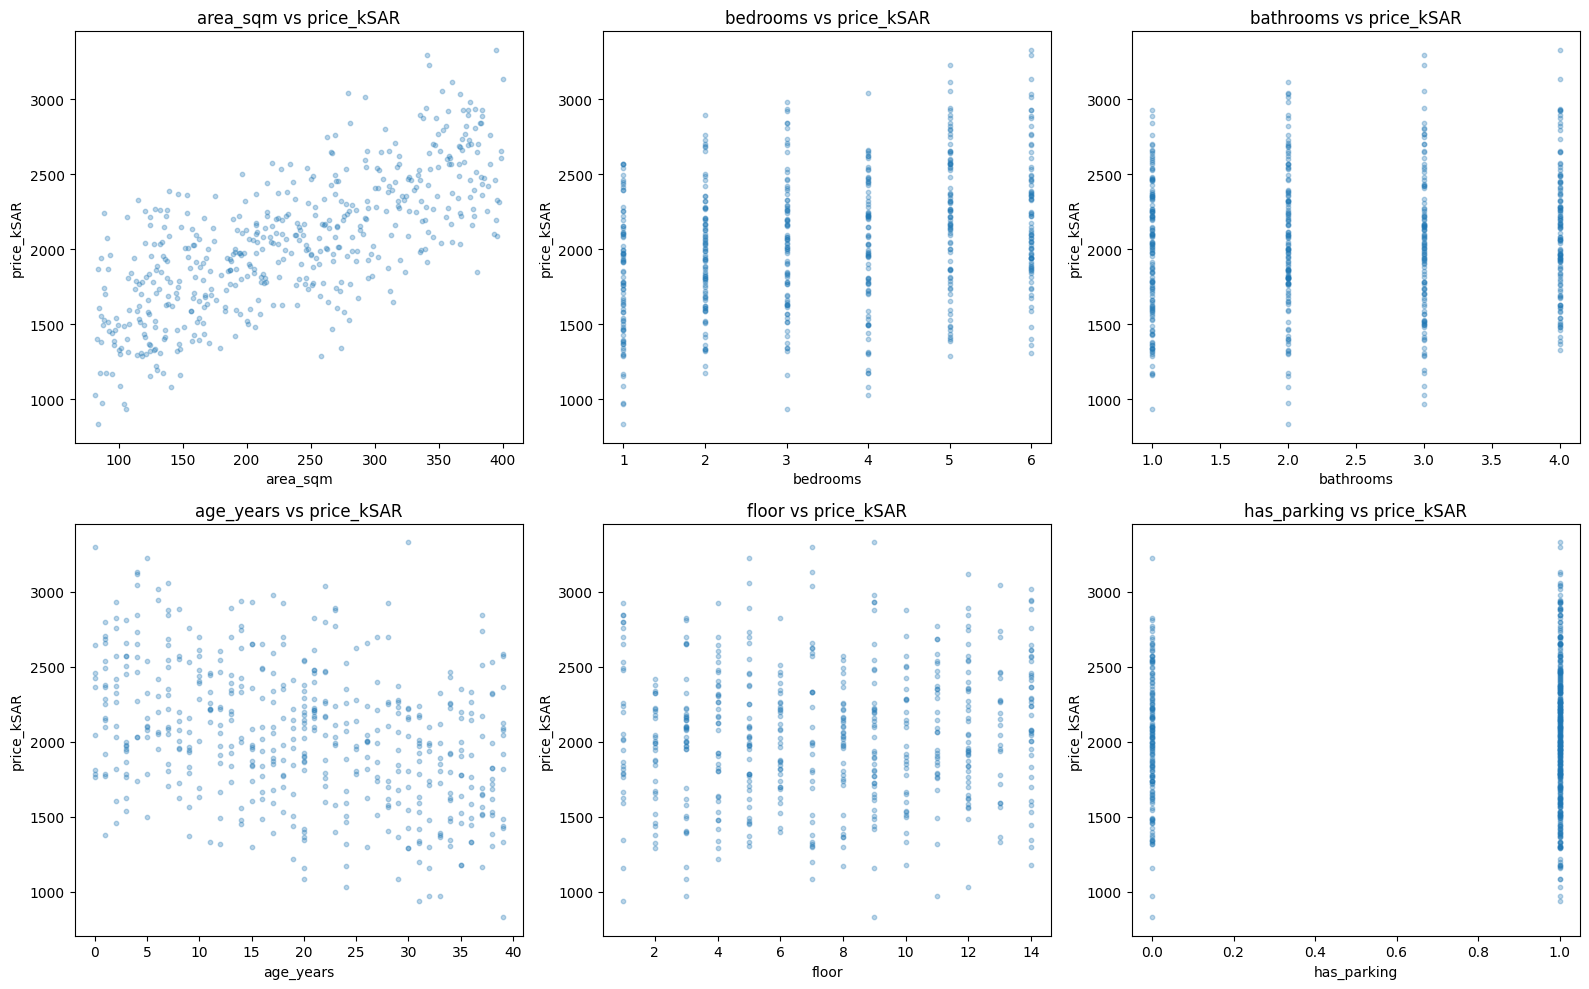

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_saudi = pd.read_csv("saudi_housing.csv")

print("Dataset shape:", df_saudi.shape)
print("\nFirst 5 rows:")
print(df_saudi.head())

print("\nBasic statistics:")
print(df_saudi.describe().round(3))

# Correlation (numeric only)
corr = df_saudi.corr(numeric_only=True)["price_kSAR"].sort_values(ascending=False)
print("\nCorrelation with price_kSAR (numeric features only):")
print(corr)

top_corr_feat = corr.index[1]  # index[0] is price_kSAR itself
print(f"\nTop correlated numeric feature with price_kSAR: {top_corr_feat} (corr = {corr[top_corr_feat]:.4f})")

# Scatter plots (numeric features vs target)
numeric_feats = ["area_sqm", "bedrooms", "bathrooms", "age_years", "floor", "has_parking"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feat in zip(axes.flatten(), numeric_feats):
    ax.scatter(df_saudi[feat], df_saudi["price_kSAR"], alpha=0.3, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel("price_kSAR")
    ax.set_title(f"{feat} vs price_kSAR")
plt.tight_layout()
plt.show()

## Task 9.1: Exploration Results

## Dataset Overview

- Dataset shape: (500, 8)
- Target variable: `price_kSAR`
- Average house price: 2044.3 thousand SAR
- Price range: 833.8 to 3326.9 thousand SAR

The dataset appears well-balanced with no missing values and realistic variation in features.

---

## Correlation with price_kSAR (Numeric Features)

Correlation values:

- area_sqm: **0.7301**
- bedrooms: 0.3000
- bathrooms: 0.0905
- floor: 0.0714
- has_parking: 0.0233
- age_years: **-0.3662**

### Most correlated feature:
**area_sqm (correlation = 0.7301)**

This is a strong positive correlation.

---

## Interpretation

1. area_sqm has the strongest positive correlation (0.73), meaning larger properties tend to have significantly higher prices.

2. age_years has a moderate negative correlation (-0.366), meaning older properties tend to be cheaper.

3. Bedrooms show a moderate positive relationship (0.30), but much weaker than area.

4. Bathrooms, floor, and parking have relatively weak direct linear correlations.

---

## Conclusion

The feature that correlates most with price is:

**area_sqm**

This makes intuitive sense because property size is typically the primary driver of housing price in real estate markets.

9.1: Answer Q1 (most correlated feature)

9.2: Preprocess (One-Hot encode city + scale numeric) + Train/Test split

In [32]:
target = "price_kSAR"
X = df_saudi.drop(columns=[target])
y = df_saudi[target].values

categorical_features = ["city"]
numeric_features = ["area_sqm", "bedrooms", "bathrooms", "age_years", "floor", "has_parking"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

9.3: Simple model (Linear Regression using only area_sqm) + plot + R²

=== Simple Linear Regression (area_sqm only) ===
RMSE: 334.6661
MAE: 276.0584
R^2: 0.4932


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


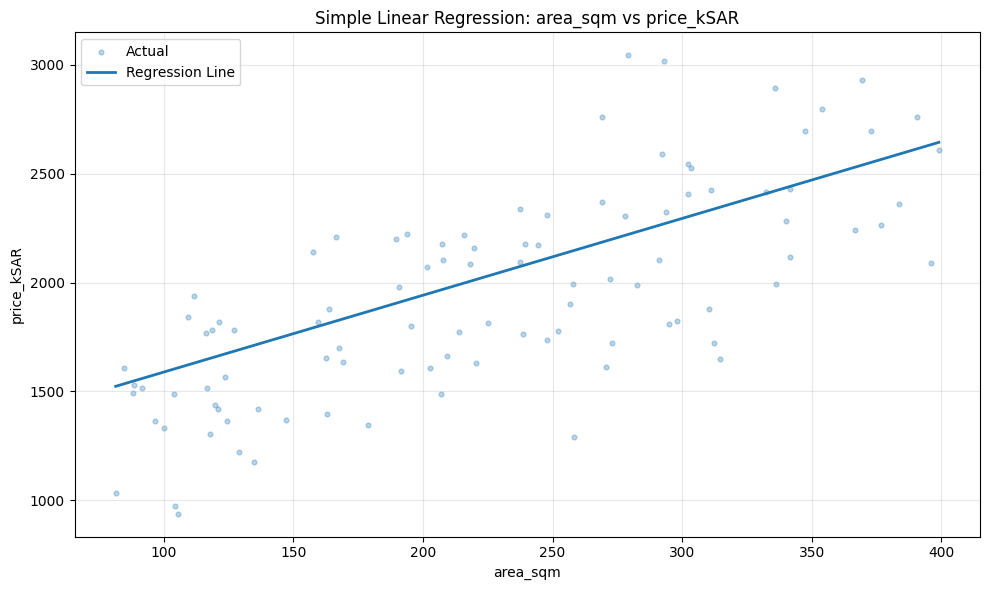

In [33]:
# Simple model: use only area_sqm
X_area = df_saudi[["area_sqm"]]
y_area = df_saudi["price_kSAR"].values

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_area, y_area, test_size=0.2, random_state=42
)

simple_area_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

simple_area_model.fit(X_train_a, y_train_a)
y_pred_a = simple_area_model.predict(X_test_a)

r2_area = r2_score(y_test_a, y_pred_a)
rmse_area = np.sqrt(mean_squared_error(y_test_a, y_pred_a))
mae_area = mean_absolute_error(y_test_a, y_pred_a)

print("=== Simple Linear Regression (area_sqm only) ===")
print(f"RMSE: {rmse_area:.4f}")
print(f"MAE: {mae_area:.4f}")
print(f"R^2: {r2_area:.4f}")

# Plot regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test_a["area_sqm"], y_test_a, alpha=0.3, s=12, label="Actual")

x_line = np.linspace(X_test_a["area_sqm"].min(), X_test_a["area_sqm"].max(), 200).reshape(-1, 1)
y_line = simple_area_model.predict(x_line)

plt.plot(x_line, y_line, linewidth=2, label="Regression Line")
plt.xlabel("area_sqm")
plt.ylabel("price_kSAR")
plt.title("Simple Linear Regression: area_sqm vs price_kSAR")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

9.4: Multiple model (all features) + improvement in R²

In [34]:
multi_lr = Pipeline([
    ("preprocess", preprocess),
    ("lr", LinearRegression())
])

multi_lr.fit(X_train, y_train)
y_pred_multi = multi_lr.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
mae_multi = mean_absolute_error(y_test, y_pred_multi)

print("=== Multiple Linear Regression (all features) ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"MAE: {mae_multi:.4f}")
print(f"R^2: {r2_multi:.4f}")

print("\nImprovement over simple area model:")
print(f" R^2: {r2_area:.4f} -> {r2_multi:.4f} (+{(r2_multi - r2_area)*100:.1f}%)")

=== Multiple Linear Regression (all features) ===
RMSE: 173.0295
MAE: 137.3012
R^2: 0.8645

Improvement over simple area model:
 R^2: 0.4932 -> 0.8645 (+37.1%)


9.5: Regularized models (Ridge, Lasso, ElasticNet) comparison

In [35]:
models = {
    "Multiple LR": Pipeline([
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]),
    "Ridge (alpha=1.0)": Pipeline([
        ("preprocess", preprocess),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]),
    "Lasso (alpha=0.01)": Pipeline([
        ("preprocess", preprocess),
        ("model", Lasso(alpha=0.01, random_state=42, max_iter=10000))
    ]),
    "ElasticNet (alpha=0.01)": Pipeline([
        ("preprocess", preprocess),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000))
    ])
}

results = []
print(f'{"Model":<22} {"RMSE":>10} {"MAE":>10} {"R^2":>10}')
print("-" * 55)

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse_v = np.sqrt(mean_squared_error(y_test, preds))
    mae_v = mean_absolute_error(y_test, preds)
    r2_v = r2_score(y_test, preds)

    results.append({"Model": name, "RMSE": rmse_v, "MAE": mae_v, "R2": r2_v})
    print(f"{name:<22} {rmse_v:>10.4f} {mae_v:>10.4f} {r2_v:>10.4f}")

Model                        RMSE        MAE        R^2
-------------------------------------------------------
Multiple LR              173.0295   137.3012     0.8645
Ridge (alpha=1.0)        173.2235   137.4361     0.8642
Lasso (alpha=0.01)       173.0356   137.3096     0.8645
ElasticNet (alpha=0.01)   173.4695   137.7345     0.8638


9.6: Lasso feature importance (most important features)

In [36]:
# Get feature names after preprocessing (scaled numeric + one-hot city)
ohe = models["Lasso (alpha=0.01)"].named_steps["preprocess"].named_transformers_["cat"]
city_feature_names = list(ohe.get_feature_names_out(["city"]))
all_feature_names = numeric_features + city_feature_names

lasso_coefs = models["Lasso (alpha=0.01)"].named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": lasso_coefs
})
coef_df["AbsCoeff"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoeff", ascending=False)

print("Top Lasso features by |coefficient|:")
print(coef_df[["Feature", "Coefficient"]].head(10).to_string(index=False))

# Also show which were removed (exactly zero)
removed = coef_df[coef_df["Coefficient"] == 0]["Feature"].tolist()
print(f"\nNumber of removed features (coef == 0): {len(removed)}")
print("Removed features:", removed)

Top Lasso features by |coefficient|:
     Feature  Coefficient
    area_sqm   333.998977
 city_Makkah   288.544529
 city_Dammam  -225.800936
    bedrooms   142.301973
   age_years  -128.050028
city_Madinah   -98.373599
       floor    74.013876
   bathrooms    53.944499
 city_Riyadh    52.018839
 has_parking    42.221681

Number of removed features (coef == 0): 1
Removed features: ['city_Jeddah']


9.7: Final comparison table (Simple area + all models) + identify best

=== Final Model Comparison (Saudi Housing) ===
                  Model       RMSE        MAE       R2
            Multiple LR 173.029522 137.301214 0.864517
     Lasso (alpha=0.01) 173.035589 137.309620 0.864508
      Ridge (alpha=1.0) 173.223528 137.436119 0.864213
ElasticNet (alpha=0.01) 173.469465 137.734487 0.863827
   Simple LR (area_sqm) 334.666127 276.058355 0.493164

Best model based on highest R^2:
Model    Multiple LR
RMSE      173.029522
MAE       137.301214
R2          0.864517


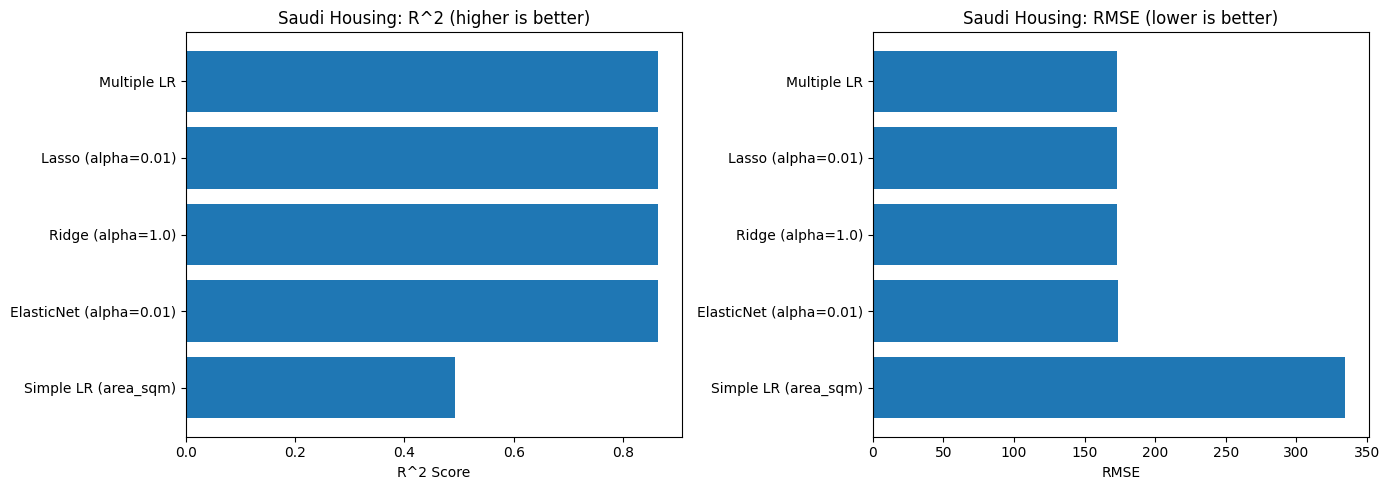

In [37]:
# Add the simple area model results into the same table for comparison
results_full = results.copy()
results_full.insert(0, {
    "Model": "Simple LR (area_sqm)",
    "RMSE": rmse_area,
    "MAE": mae_area,
    "R2": r2_area
})

comp_df = pd.DataFrame(results_full).sort_values("R2", ascending=False)

print("=== Final Model Comparison (Saudi Housing) ===")
print(comp_df.to_string(index=False))

best_row = comp_df.iloc[0]
print("\nBest model based on highest R^2:")
print(best_row.to_string())

# Optional: visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comp_df["Model"], comp_df["R2"])
axes[0].set_xlabel("R^2 Score")
axes[0].set_title("Saudi Housing: R^2 (higher is better)")
axes[0].invert_yaxis()

axes[1].barh(comp_df["Model"], comp_df["RMSE"])
axes[1].set_xlabel("RMSE")
axes[1].set_title("Saudi Housing: RMSE (lower is better)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

9.8: Final written conclusions for Task 9

# Final Conclusion: Saudi Housing Analysis

## 1) Overall Model Performance

The best performing model was:

**Multiple Linear Regression (all features)**  
- R² = 0.8645  
- RMSE = 173.03  
- MAE = 137.30  

This model explains approximately **86.45% of the variance** in Saudi housing prices, which indicates very strong predictive performance.

The simple model using only `area_sqm` performed significantly worse:
- R² = 0.4932  
- RMSE = 334.67  

Adding all features improved R² by **37.1%**, showing that price is influenced by multiple factors beyond just size.

---

## 2) Regularization Models

Ridge, Lasso, and ElasticNet produced almost identical results to standard Multiple Linear Regression:

- Ridge R² = 0.8642  
- Lasso R² = 0.8645  
- ElasticNet R² = 0.8638  

This happens because:
- The dataset is well-structured.
- There is no severe multicollinearity.
- The number of features is moderate.
- The synthetic data follows a mostly linear relationship.

Therefore, regularization does not significantly change performance in this case.

---

## 3) Feature Importance (Lasso Interpretation)

Top important features identified by Lasso:

- area_sqm (strongest positive effect)
- city_Makkah (strong positive effect)
- city_Dammam (strong negative effect)
- bedrooms
- age_years (negative effect)

This matches intuition:
- Larger houses cost more.
- Makkah has higher base prices.
- Dammam has lower base prices.
- More bedrooms increase value.
- Older houses reduce value.

Lasso removed only one feature (`city_Jeddah`), meaning most features contribute meaningfully.

---

## 4) Final Model Recommendation

If deploying this model for a Saudi real estate company, the best choice would be:

**Multiple Linear Regression (all features)**

Reasons:
- Highest R² (0.8645)
- Lowest RMSE
- Simple and interpretable
- No unnecessary complexity
- Easy to explain to stakeholders

Although regularized models perform similarly, standard Multiple Linear Regression is sufficient and fully captures the price relationships in this dataset.

---

## 5) Final Summary

This analysis demonstrates that Saudi housing prices are primarily driven by:

- Property size (area_sqm)
- Location (city)
- Number of bedrooms
- Property age

Using proper preprocessing (One-Hot encoding + scaling) and pipelines ensures clean, reproducible modeling.

The final model provides high accuracy while maintaining interpretability, making it suitable for real-world deployment.

#short report

The regression models showed a clear improvement when moving from a simple model using only area to a multiple-feature model. The simple linear regression achieved an R² of 0.4932, while the multiple linear regression increased performance significantly to an R² of 0.8645, reducing RMSE from 334.67 to 173.03. Among all models tested, Multiple Linear Regression performed best, with Lasso and Ridge producing nearly identical results. Regularization (Ridge, Lasso, and ElasticNet) did not significantly improve performance because the dataset is well-behaved and mostly linear, with limited multicollinearity. Lasso revealed that area_sqm was the most predictive feature, followed by city effects (especially Makkah and Dammam), bedrooms, and age_years. Overall, housing prices were primarily driven by property size, location, and structural characteristics, and a standard multiple linear regression model was sufficient to achieve strong predictive accuracy.